# Agent AI - BACEN SGS Time-series analysis assistant - One variable at a time

##  NLP classification problem : Text(prompt) similarity/classification performance approach 

As a preliminary exercise, we will first pass a text as an input string  and  comopare to a previuos defined dictionary BACEN time_series and then get the most suitable string. 

With the most suitable series, we will run time-series pre-process analysis. 

In [3]:
# fetch_bacen.py
import requests # access HTTP content
from requests.adapters import HTTPAdapter, Retry
import pandas as pd # lib for data manipulation

from tqdm import trange # lib for progress bars
import unicodedata # text normalization

import difflib
from difflib import SequenceMatcher
from bcb import sgs
import re

## langChain
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

## Timne-series diagnostics tests
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

### Create dictionary of top series from BACEN

In [4]:
BACEN_TOP_SERIES = {
    # 🔹 External sector
    "reservas internacionais total diária": 13621,
    "transações correntes mensal saldo": 22701,

    # 🔹 Interest rates
    "taxa selic diária": 11,
    "taxa selic meta definida pelo copom": 432,
    "taxa selic acumulada no mês": 4390,
    "taxa selic anualizada base 252": 1178,
    "taxa básica financeira tbf": 253,
    "taxa referencial tr": 226,

    # 🔹 Credit and savings
    "Saldo diário de depósitos de poupança - SBPE": 239,
    # "Taxa média de depósitos de poupança (rentabilidade)": 195,
    "taxa média de juros pessoas físicas total": 20716,
    "taxa média de juros pessoas jurídicas total": 20715,
    "taxa média de juros total": 20714,
    "indicador de custo do crédito icc": 25359,

    # 🔹 Inflation indices (CPI)
    "Índice nacional de preços ao consumidor-amplo (IPCA)": 433,
    "Índice nacional de preços ao consumidor-Amplo (IPCA) - Núcleo médias aparadas com suavização": 4466,
    "ipca 15 índice nacional de preços ao consumidor amplo 15": 11428,
    "inpc índice nacional de preços ao consumidor": 188,

    # 🔹 Monetary aggregates
    "base monetária ampliada títulos do tesouro nacional carteira do mercado": 1831,
    "base monetária ampliada títulos do tesouro nacional financiamento líquido": 1832,
    "meios de pagamento ampliados operações compromissadas selic": 1839,
    "meios de pagamento ampliados títulos federais em poder do público selic": 1841,
    "dívida mobiliária participação por indexador posição de custódia": 2238,
    "dívida mobiliária participação por indexador posição em carteira": 4177,

    # 🔹 GDP and Activity
    "pib produto interno bruto trimestral": 4380,
    "pib nominal preço de mercado trimestral": 4382,
    "ibc br índice de atividade econômica do banco central mensal dessazonalizado": 24364,
    "ibc br índice de atividade econômica do banco central mensal original": 24363,

    # 🔹 Inflation expectations (Focus survey)
    "expectativa ipca 12 meses focus média": 4333,

    # 🔹 Exchange rates
    "câmbio comercial venda r$/us$ média": 10813,
    "câmbio efetivo real índice jan 2005 = 100": 11752,
    "câmbio nominal índice jan 2005 = 100": 11753,
}

# TOP_SERIES_CODES = list(BACEN_TOP_SERIES.values())
# TOP_SERIES_CODES

### Create helper functions to make the query text suitable

In [5]:
# # Normalize text prompt for better matching 
def normalize_text(text):
    """
    Normalize text for robust fuzzy matching:
    - Lowercase
    - Remove accents
    - Remove punctuation and symbols
    - Collapse multiple spaces
    """
    if not isinstance(text, str):
        return ""
    # Lowercase and strip
    text = text.lower().strip()

    # Remove accents (normalize to NFD and strip combining marks)
    text = ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

    # Remove punctuation, symbols, and non-alphanumeric chars (keep spaces)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# get the BACEN CODE from a text prompt
def find_bacen_code(prompt, dictionary=BACEN_TOP_SERIES, cutoff=0.3, verbose=True):
    """Find the BACEN code by fuzzy best match or partial text match."""

    # Normalize prompt and dictionary keys
    q = normalize_text(prompt)
    normalized_dict = {normalize_text(k): v for k, v in dictionary.items()}

    # Fuzzy best match
    match = difflib.get_close_matches(q, normalized_dict.keys(), n=1, cutoff=cutoff)
    if match:
        best_key = match[0]
        code = normalized_dict[best_key]
        if verbose:
            print(f"Fuzzy match: '{best_key}' → code {code}")
        return code

    # Partial substring match
    partial_matches = {k: v for k, v in normalized_dict.items() if q in k}
    if partial_matches:
        best_key = max(partial_matches, key=len)
        best_code = partial_matches[best_key]
        if verbose:
            print(f"Partial match: '{best_key}' → code {best_code}")
        return best_code

    ## No match
    print("No match found.")
    return None

### Test prompt

In [6]:
print(find_bacen_code("expectativa de IPCA focus média"))
print(find_bacen_code("cambio"))
# find_bacen_code("Selic")
print(find_bacen_code("saldo poupança"))

print(find_bacen_code("selic do Brasil"))

Fuzzy match: 'expectativa ipca 12 meses focus media' → code 4333
4333
Fuzzy match: 'cambio comercial venda r us media' → code 10813
10813
Fuzzy match: 'saldo diario de depositos de poupanca sbpe' → code 239
239
Fuzzy match: 'taxa selic diaria' → code 11
11


## Get data from SGS BACEN

In [7]:
df = sgs.get({'Selic': 4390}, start='2015-01-01', end='2021-01-01')
df.tail()

,Selic
Date,
2020-09-01,0.16
2020-10-01,0.16
2020-11-01,0.15
2020-12-01,0.16
2021-01-01,0.15


In [8]:
#### fetch data from BACEN function 
def fetch_bacen_series(code, start=None, end=None):
    df = sgs.get({str(code): code}, start=start, end=end)
    print(f"Retrieved {len(df)} rows for code {code}.")
    return df   

## Prompt 1 (very small text)

In [9]:
def bacen_agent(prompt, dictionary, start=None, end=None):
    """
    Understands the prompt, finds the right BACEN code, and loads the data.
    """
    print(f"\nProcessing prompt: '{prompt}'")

    # Extract tokens from the prompt and normalize
    text = prompt.lower()
    tokens = re.findall(r"[a-zA-ZçÇãõáéíóúâêîôûàèìòù]+", text)
    print(f"Extracted tokens: {tokens}")

    found_code = None
    for token in tokens:
        code = find_bacen_code(token, dictionary)
        if code:
            found_code = code
            print(f"Found match for token '{token}' → code {code}")
            break

    if not found_code:
        print("⚠️ No BACEN code detected in prompt.")
        return pd.DataFrame()  # Return empty DF, not None

    # Fetch the data
    try:
        df = sgs.get({str(found_code): found_code}, start=start, end=end)
        df = df.reset_index().rename(columns={"index": "Date", found_code: "Value"})
        print(f"Retrieved {len(df)} rows for code {found_code}.")
        return df
    except Exception as e:
        print(f"❌ Error retrieving BACEN data: {e}")
        return pd.DataFrame()

In [10]:
df_ipca = bacen_agent(
    "cambio",
    BACEN_TOP_SERIES,
    start="2020-01-01",
    end="2023-12-31"
)
print(df_ipca.tail())


Processing prompt: 'cambio'
Extracted tokens: ['cambio']
Fuzzy match: 'cambio comercial venda r us media' → code 10813
Found match for token 'cambio' → code 10813
Retrieved 1002 rows for code 10813.
           Date   10813
997  2023-12-22  4.8613
998  2023-12-26  4.8362
999  2023-12-27  4.8300
1000 2023-12-28  4.8407
1001 2023-12-29  4.8407


## Prompt 2 (bigger prompt)

We should make as default values:
* BACEN_TOP_SERIES as the default dictionary;
* todays_date as the max default end date
    * Notice that I can pass the dates anyway I want, but the default value is todays date

In [11]:
### smnall dictionary - just for texting

BACEN_TOP_SERIES = {

    #  Interest rates
    "taxa selic meta definida pelo copom": 432,
    "taxa selic acumulada no mês": 4390,
    "taxa selic anualizada base 252": 1178,
    "taxa básica financeira tbf": 253,
    "taxa referencial tr": 226,
    "taxa selic diária": 11,

    # Exchange rates
    "câmbio comercial venda r$/us$ média": 10813,
    "câmbio efetivo real índice jan 2005 = 100": 11752,
    "câmbio nominal índice jan 2005 = 100": 11753,
}


In [12]:
def bacen_agent_load(prompt, dictionary=BACEN_TOP_SERIES, start=None, end=pd.Timestamp.now().normalize()):
    """Understands the prompt, finds the right BACEN code, and loads the data."""
    print(f"\nProcessing prompt: '{prompt}'")

    text = prompt.lower()
    tokens = re.findall(r"[a-zA-ZçÇãõáéíóúâêîôûàèìòù]+", text)
    print(f"Extracted tokens: {tokens}")

    # --- Find best match ---
    found_code = find_bacen_code(prompt, dictionary)
    if found_code:
        print(f"Direct match using full prompt → code {found_code}")
    else:
        for size in range(len(tokens), 0, -1):
            for i in range(len(tokens) - size + 1):
                segment = " ".join(tokens[i:i+size])
                code = find_bacen_code(segment, dictionary)
                if code:
                    found_code = code
                    print(f"Found match with segment '{segment}' → code {code}")
                    break
            if found_code:
                break

    if not found_code:
        print("No BACEN code detected in prompt.")
        return pd.DataFrame(), None

    # --- Fetch the data ---
    try:
        df = sgs.get({str(found_code): found_code}, start=start, end=end)
        df = df.reset_index().rename(columns={"index": "Date", str(found_code): "Value"})
        print(f"Retrieved {len(df)} rows for code {found_code}.")
        return df, found_code
    except Exception as e:
        print(f"Error retrieving data for code {found_code}: {e}")
        return pd.DataFrame(), found_code

In [13]:
### Reset end_date to yesterday
end = pd.Timestamp.now().normalize() - pd.Timedelta(days=1)

df_cambio, code = bacen_agent_load(
    "cambio", 
    start="2020-01-01", 
    end=end)

print(df_cambio.tail())


Processing prompt: 'cambio'
Extracted tokens: ['cambio']
Fuzzy match: 'cambio comercial venda r us media' → code 10813
Direct match using full prompt → code 10813
Retrieved 1454 rows for code 10813.
           Date   Value
1449 2025-10-09  5.3532
1450 2025-10-10  5.4440
1451 2025-10-13  5.4623
1452 2025-10-14  5.4976
1453 2025-10-15  5.4458


### One stop further -= Display all possible tokens candidates

1. list all possible matches above a similarity threshold (say, cutoff = 0.3).

2. auto-select the one with the smallest code value (as you suggested).

Make debugging easier — show all candidate matches and their similarity scores.

In [14]:
def bacen_agent_load(prompt, dictionary=BACEN_TOP_SERIES, start=None, end=pd.Timestamp.now().normalize(), cutoff=0.3):
    """Understands the prompt, finds the right BACEN code, lists possible similar matches, and loads the data."""
    print(f"\nProcessing prompt: '{prompt}'")

    # --- Tokenize and normalize ---
    text = normalize_text(prompt)
    tokens = text.split()
    print(f"Extracted tokens: {tokens}")

    # --- Normalize dictionary ---
    normalized_dict = {normalize_text(k): v for k, v in dictionary.items()}

    # --- Filter dictionary to keys that contain any query token ---
    filtered_items = {
        k: v for k, v in normalized_dict.items()
        if any(tok in k for tok in tokens)
    }

    if not filtered_items:
        print("⚠️ No partial matches found based on tokens.")
        return pd.DataFrame(), None

    # --- Compute similarity only within filtered subset ---
    scored = []
    for key, code in filtered_items.items():
        sim = SequenceMatcher(None, text, key).ratio()
        if sim >= cutoff:
            scored.append((key, code, sim))

    if not scored:
        print(f"⚠️ No matches above cutoff {cutoff}.")
        return pd.DataFrame(), None

    scored.sort(key=lambda x: (-x[2], x[1]))

    # --- Display ---
    print(f"\n🔍 Possible matches (similarity ≥ {cutoff}):")
    for key, code, sim in scored:
        print(f"  • {key:<80} → code {code:<6} (similarity={sim:.2f})")

    best_key, best_code, best_sim = scored[0]
    print(f"\nBest match selected: '{best_key}' → code {best_code} (similarity={best_sim:.2f})")

  
    # --- Fetch data ---
    try:
        df = sgs.get(best_code, start=start, end=end)  # use numeric directly
        df = df.reset_index().rename(columns={"index": "Date", best_code: "Value"})
        print(f"Retrieved {len(df)} rows for code {best_code}.")
        return df, best_code

    except Exception as e:
        print(f"❌ Error retrieving data for code {best_code}: {e}")
        return pd.DataFrame(), best_code

In [15]:
df, code = bacen_agent_load("taxa selic diária praticada no Brasil hoje", start="2020-01-01")


Processing prompt: 'taxa selic diária praticada no Brasil hoje'
Extracted tokens: ['taxa', 'selic', 'diaria', 'praticada', 'no', 'brasil', 'hoje']

🔍 Possible matches (similarity ≥ 0.3):
  • taxa selic acumulada no mes                                                      → code 4390   (similarity=0.61)
  • taxa selic diaria                                                                → code 11     (similarity=0.58)
  • taxa selic anualizada base 252                                                   → code 1178   (similarity=0.56)
  • taxa selic meta definida pelo copom                                              → code 432    (similarity=0.52)
  • taxa referencial tr                                                              → code 226    (similarity=0.36)
  • taxa basica financeira tbf                                                       → code 253    (similarity=0.35)

Best match selected: 'taxa selic acumulada no mes' → code 4390 (similarity=0.61)
Retrieved 70 rows for code 4

### Preliinary Takeaways:

* SequenceMatcher is doing surface-level character overlap, which is weak for semantically similar phrases (e.g. “taxa selic diária praticada no Brasil hoje” vs “taxa selic diaria”).

    * Penalizes word order changes,
    * Ignores meaning,
    * Fails when extra words dilute the match;
    * Need to upgrade the AI Agent to use semantic similarity with embeddings (LangChain) — while keeping it compatible with your current dictionary. 

## LangChain

Dnloaded and loaded correctly

In [16]:
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

#### Confirms thatv the model is proper instantiated 

In [17]:
embed = embedder.encode(["taxa selic diaria", "cambio nominal"], normalize_embeddings=True)
print(embed.shape)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(2, 384)


### Vectorize your BACEN dictionary ( split keys and values)

In [18]:
bacen_keys = list(BACEN_TOP_SERIES.keys())
bacen_codes = list(BACEN_TOP_SERIES.values())

bacen_embeddings = embedder.encode(bacen_keys, convert_to_numpy=True, normalize_embeddings=True)
bacen_embeddings

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

array([[-3.2700986e-02,  7.3257372e-02, -3.1427946e-02, ...,
        -2.5970051e-02, -4.2434677e-02,  2.9390039e-02],
       [-1.4046100e-02, -2.3251816e-03, -1.2519105e-02, ...,
        -1.8528590e-02, -2.1418622e-02,  7.5968169e-03],
       [-1.5758129e-02,  1.9182689e-02, -6.0848910e-02, ...,
        -6.5785266e-02,  2.0796393e-05, -3.8463075e-02],
       ...,
       [ 2.5344539e-02, -5.9012420e-02, -4.9318470e-02, ...,
        -9.1505878e-02, -6.7953847e-02, -8.0800410e-03],
       [-4.0235814e-02, -2.9710529e-02, -1.8897094e-02, ...,
        -4.3989047e-02, -5.5783685e-02,  5.0807353e-03],
       [ 1.3157772e-03,  1.3806778e-02,  4.5596011e-04, ...,
        -3.5371233e-02, -4.6775721e-02, -1.0270984e-02]], dtype=float32)

## Prompt 3 - LangChain text 

In [19]:
query = "taxa selic diária praticada no Brasil hoje"
q_emb = embedder.encode([query], normalize_embeddings=True)

sims = cosine_similarity(q_emb, bacen_embeddings)[0]
print(sims)
top_idx = sims.argmax()

print(f"Best series selected: '{bacen_keys[top_idx]}' | Code: {bacen_codes[top_idx]} | Similarity: {sims[top_idx]:.2f}")


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[0.3843967  0.5455853  0.46834332 0.32501265 0.36366364 0.6595599
 0.37212527 0.4383738  0.43096873]
Best series selected: 'taxa selic diária' | Code: 11 | Similarity: 0.66


### Update bacen_agent_load function to use LangChain steps

In [20]:
def bacen_agent_load_langchain(prompt, dictionary=BACEN_TOP_SERIES, start=None, end=None, cutoff=0.35):
    """
    Intelligent BACEN data retriever & analyzer using LangChain embeddings.
    1. Uses semantic similarity (SentenceTransformer) to match prompt → BACEN code.
    2. Fetches data automatically.
    3. Returns df, code, and similarity score.
    """

    if start is None:
        start="2020-01-01"

    if end is None:
        end = pd.Timestamp.now().normalize()

    # --- Step 1: Vectorize your BACEN dictionary ( split keys and values) ---
    bacen_keys = list(dictionary.keys())
    bacen_codes = list(dictionary.values())
    bacen_embs = embedder.encode(bacen_keys, convert_to_numpy=True, normalize_embeddings=True)

     # --- Step 2: Semantic search ---
    q_emb = embedder.encode([prompt], normalize_embeddings=True)
    sims = cosine_similarity(q_emb, bacen_embs)[0]
    top_idx = sims.argmax()

    best_key = bacen_keys[top_idx]
    best_code = bacen_codes[top_idx]
    best_sim = sims[top_idx]

    print(f"Best series selected: '{best_key}' | Code: {best_code} | Similarity: {best_sim:.2f}")

    # --- Step 3: Fetch BACEN data ---
    try:
        df = sgs.get(best_code, start=start, end=end)
        df = df.reset_index().rename(columns={"index": "Date", best_code: "Value"})
        print(f"Retrieved {len(df)} rows for code {best_code}.")
    except Exception as e:
        print(f"❌ Error retrieving series {best_code}: {e}")
        return pd.DataFrame(), best_code

    return df, best_code, best_key, best_sim


## Outputs - Time Seriesd Charts

In [21]:
df, code, best_key, sim =  bacen_agent_load_langchain("cambio comercial", start="2021-01-01")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Best series selected: 'câmbio comercial venda r$/us$ média' | Code: 10813 | Similarity: 0.47
Retrieved 1204 rows for code 10813.


In [24]:
def bacen_agent_plot(df, code):
    """
    Fetch, analyze, and plot BACEN series using LangChain-based semantic matching
    """

    if df.empty:
        print("⚠️ No data to plot.")
        return

    if "Value" not in df.columns:
        df = df.rename(columns={df.columns[-1]: "Value"})

    # --- Prepare data ---
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()
    df_returns = df["Value"].pct_change() * 100

    # --- Detect frequency ---
    freq_days = df.index.to_series().diff().median().days
    if freq_days <= 2:
        freq_type = "daily"
        df_resampled = df["Value"].resample("W").mean()
        period = 52
    elif freq_days < 25:
        freq_type = "monthly"
        df_resampled = df["Value"].resample("M").mean()
        period = 12
    else:
        freq_type = "annual"
        df_resampled = df["Value"].copy()
        period = None

    print(f"Detected {freq_type} data → using resampled freq = {df_resampled.index.freqstr or 'W/M'}")

    # --- Plot layout ---
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    fig.suptitle(f"BACEN Time  Series {code}", fontsize=12, fontweight="bold")

    axes[0, 0].plot(df.index, df["Value"], color="tab:blue", linewidth=1.5)
    axes[0, 0].set_title("Original Series")

    axes[0, 1].plot(df.index, df_returns, color="tab:orange", linewidth=1)
    axes[0, 1].axhline(0, color="black", linewidth=0.8)
    axes[0, 1].set_title("Returns (Δyₜ / yₜ₋₁)")

    try:
        result = seasonal_decompose(df_resampled.dropna(), model="additive", period=period)
        axes[1, 0].plot(result.trend, color="tab:green")
        axes[1, 0].set_title("Trend")
        axes[1, 1].plot(result.seasonal, color="tab:purple")
        axes[1, 1].set_title("Seasonal (Resampled)")
    except Exception as e:
        print(f"⚠️ Decomposition failed: {e}")

    for ax in axes.flat:
        ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

Detected daily data → using resampled freq = W-SUN


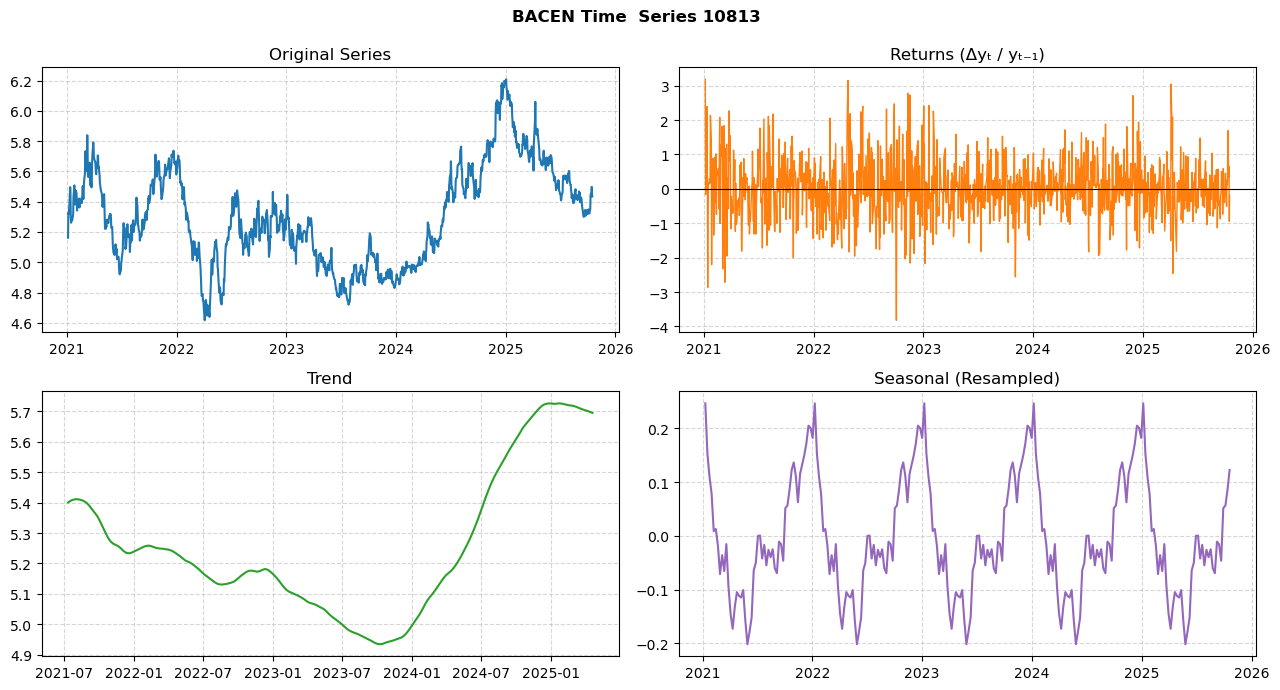

In [25]:
bacen_agent_plot(df, code)

###  Pre-test for time-series

In [26]:
def time_series_diagnostics(df, lags=12, use_returns=False, title="Time-Series Diagnostics"):
    """
    Compute descriptive and diagnostic statistics for a BACEN time series DataFrame.
    Tests: Descriptive stats, ADF, Ljung-Box (Q and Q²), ARCH LM.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns ['Date', 'Value'].
    lags : int
        Number of lags for autocorrelation tests.
    use_returns : bool
        If True, compute statistics on percentage returns (Δy/yₜ₋₁ * 100) and not on raw_values.
    title : str
        Optional title for printed output.
    """

    if df.empty:
        print("⚠️ No data provided.")
        return

    # --- Ensure proper column names and sorting ---
    if "Value" not in df.columns:
        df = df.rename(columns={df.columns[-1]: "Value"})

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").set_index("Date")

    # --- Use raw levels or returns ---
    if use_returns:
        df["Value"] = df["Value"].pct_change() * 100
        df = df.dropna()
        print("Using percentage returns (Δy/yₜ₋₁ * 100).")

    series = df["Value"]

    # --- Descriptive statistics ---
    n = len(series)
    mean = series.mean()
    std = series.std()
    skew = stats.skew(series)
    kurt = stats.kurtosis(series)
    jb_stat, jb_p = stats.jarque_bera(series)

    # --- Stationarity (ADF test) ---
    try:
        adf_result = adfuller(series, autolag="AIC")
        # adf_stat =  adf_result[0]
        adf_p = adf_result[1]
    except Exception as e:
        print(f"⚠️ ADF test failed: {e}")

    # --- Autocorrelation (Ljung-Box) ---
    lb_results = acorr_ljungbox(df, lags=[12], return_df=True)
    lbq_p = lb_results['lb_pvalue'].values[0]

    # # --- Ljung-Box on squared series (heteroskedasticity) ---
    lb2_results = acorr_ljungbox(df**2, lags=[lags], return_df=False)
    # lbq2_stat = lb2_results['lb_stat'].values[0]
    lbq2_p = lb2_results['lb_pvalue'].values[0]

    # --- ARCH LM test ---
    arch_results = het_arch(series)
    # arch_stat = arch_results[0]
    arch_p = arch_results[1]

    # --- Summary Table ---
    df_diag = pd.DataFrame({
        "Statistic": [
            "Number of observations", 
            "Mean", 
            "Standard deviation",
            "Skewness", 
            "Kurtosis", 
            "Jarque-Bera (p)",
            "ADF (p)",
            "Ljung-Box Q-test (p)", 
            "Ljung-Box Q²-test (p)", 
            "ARCH test (p)"
        ],
        "Value": [
            n,
            round(mean,4),
            round(std,4),
            round(skew,4),
            round(kurt,4),
            round(jb_p,4),
            round(adf_p,4),
            round(lbq_p,4),
            round(lbq2_p,4),
            round(arch_p,4)
        ]
    })

    return df_diag

In [27]:
diag = time_series_diagnostics(df, use_returns=True, lags=12, title=f"BACEN Series {code}")
diag

Using percentage returns (Δy/yₜ₋₁ * 100).


,Statistic,Value
0,Number of observations,1203.0000
1,Mean,0.0077
2,Standard deviation,0.8284
3,Skewness,0.1761
4,Kurtosis,1.2672
5,Jarque-Bera (p),0.0000
6,ADF (p),0.0000
7,Ljung-Box Q-test (p),0.0085
8,Ljung-Box Q²-test (p),0.0000
9,ARCH test (p),0.0000


### Compute lag definition plots

In [42]:
def plot_acf_pacf(df, lags=24, use_returns=False, title="ACF/PACF Diagnostics"):
    """
    Plot ACF and PACF for BACEN series (levels and/or returns).
    """

    if "Value" not in df.columns:
        df = df.rename(columns={df.columns[-1]: "Value"})

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()

    if use_returns:
        series = df["Value"].pct_change() * 100
        series = series.dropna()
        label = "Percentage Returns (Δy/yₜ₋₁ * 100)"
    else:
        series = df["Value"]
        label = "Raw Series (Levels)"

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    fig.suptitle(f"{title} – {label}", fontsize=12, fontweight="bold")

    plot_acf(series, ax=axes[0], lags=lags, alpha=0.05)
    axes[0].set_title("ACF")

    plot_pacf(series, ax=axes[1], lags=lags, alpha=0.05, method="ywm")
    axes[1].set_title("PACF")

    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

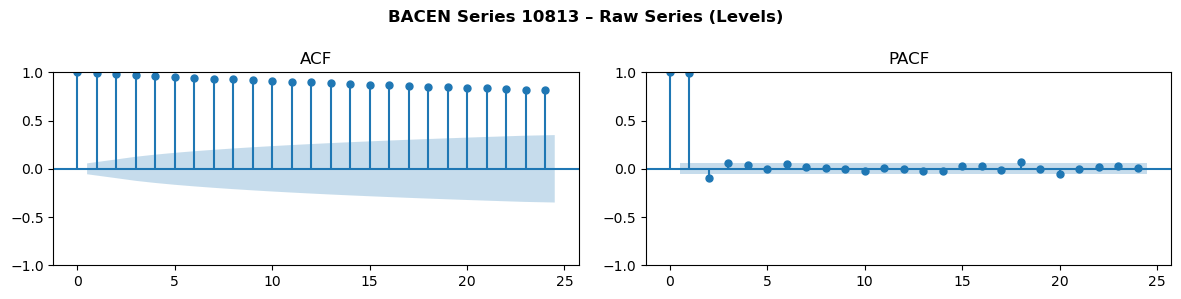

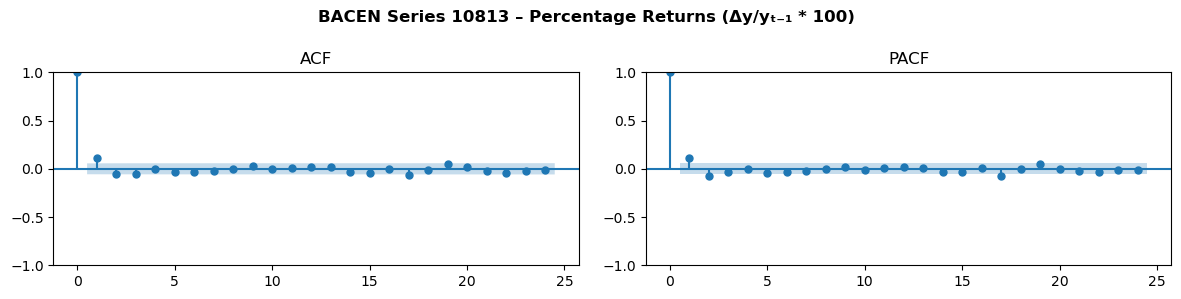

In [44]:
#### plot_acf_pacf(df, lags=24, use_returns=False, title=f"BACEN Series {code}")
plot_acf_pacf(df, lags=24, use_returns=False, title=f"BACEN Series {code}")
plot_acf_pacf(df, lags=24, use_returns=True, title=f"BACEN Series {code}")